In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.preprocessing import LabelEncoder

In [2]:
xls = pd.ExcelFile("heart_disease.xlsx")
xls.sheet_names

['Description', 'Heart_disease']

In [3]:
df = pd.read_excel("heart_disease.xlsx", sheet_name="Heart_disease")

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [6]:
df.shape

(908, 13)

In [7]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [8]:
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [9]:
df['oldpeak'].fillna(df['oldpeak'].median(), inplace=True)

In [10]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

In [11]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
903    False
904    False
905    False
906    False
907    False
Length: 908, dtype: bool

In [12]:
df.drop_duplicates(inplace=True)

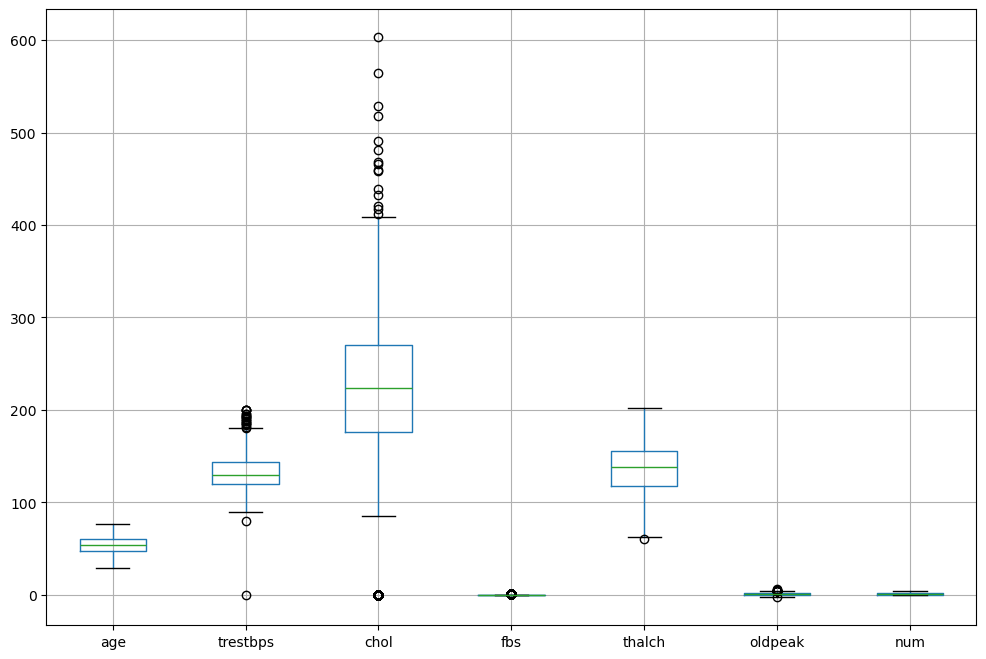

In [13]:
df.boxplot(figsize=(12,8))
plt.show()

In [14]:
num_cols = df.select_dtypes(include=['int', 'float']).columns
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

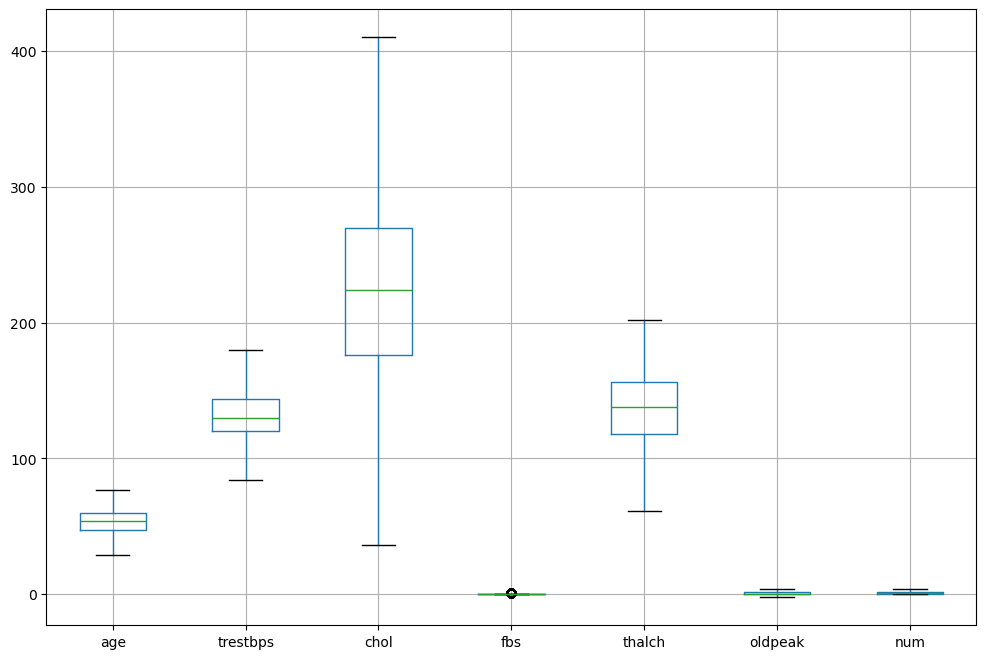

In [15]:
df.boxplot(figsize=(12,8))
plt.show()

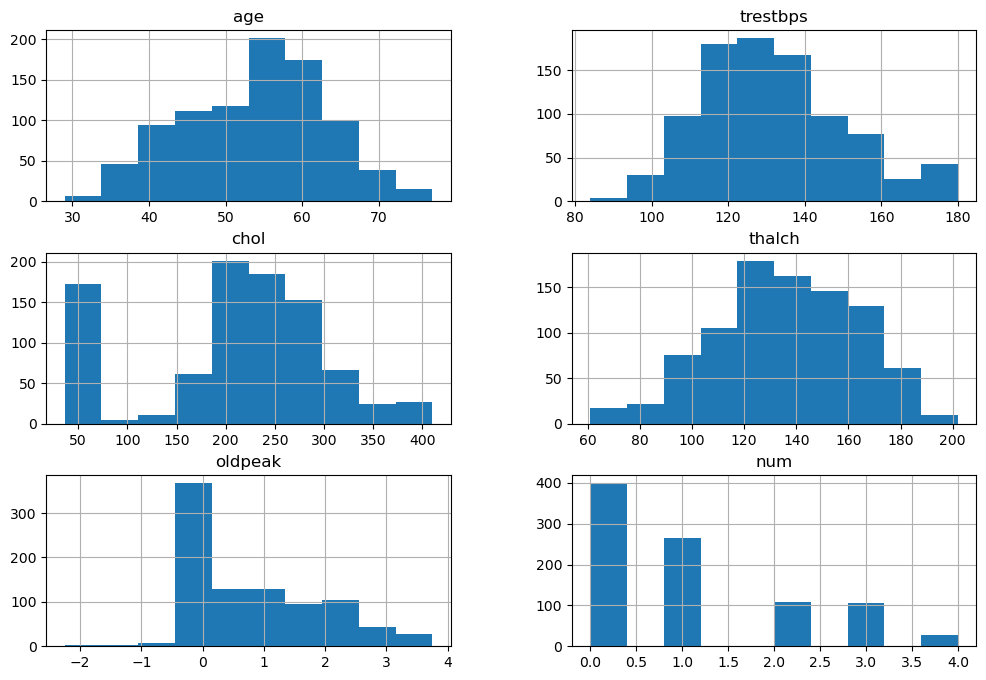

In [16]:
df.hist(figsize=(12,8))
plt.show()

In [17]:
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')

<Axes: >

In [18]:
lebel = LabelEncoder()

In [19]:
cate_col = df.select_dtypes(include='object').columns

In [20]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str)

In [21]:
le = LabelEncoder()
for col in cate_col:
    df[col] = le.fit_transform(df[col])

In [22]:
features = df.drop('num', axis=1)
target = df['num']

In [23]:
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

In [24]:
dt_model=DecisionTreeClassifier()
dt_model.fit(x_train,y_train)

DecisionTreeClassifier()

In [25]:
y_pred=dt_model.predict(x_test)
acc_score=accuracy_score(y_test,y_pred)
print('Accuracy Score is:',acc_score)

Accuracy Score is: 0.554945054945055


In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.79      0.73      0.76        89
         1.0       0.44      0.55      0.49        47
         2.0       0.27      0.30      0.29        20
         3.0       0.25      0.24      0.24        17
         4.0       0.00      0.00      0.00         9

    accuracy                           0.55       182
   macro avg       0.35      0.36      0.36       182
weighted avg       0.55      0.55      0.55       182



In [27]:
### hyperparamter tuning
param_grid = {
    "max_depth": [3,5,7,10,None],
    "min_samples_split": [2,5,10],
    "criterion": ["gini", "entropy"]
}

In [33]:
grid = GridSearchCV(DecisionTreeClassifier(random_state=42),param_grid,cv=5,scoring="f1")

In [34]:
grid.fit(x_train, y_train)
best_model = grid.best_estimator_
grid.best_params_

{'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}

In [35]:
dt_model2=DecisionTreeClassifier(criterion='entropy',max_depth=3,
    min_samples_split=2,
    min_samples_leaf=5,)
dt_model2.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, min_samples_leaf=5)

In [36]:
y_pred2=dt_model2.predict(x_test)
acc_score=accuracy_score(y_test,y_pred2)
print('Accuracy Score is:',acc_score)

Accuracy Score is: 0.5659340659340659


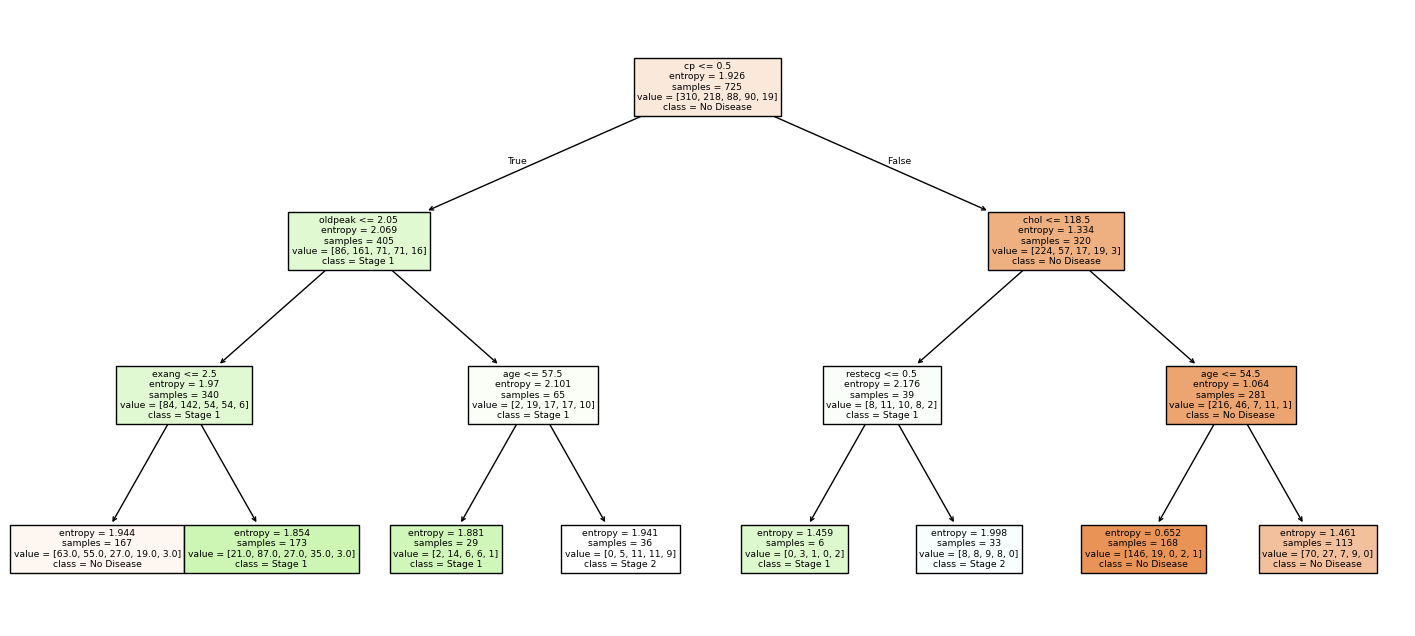

In [37]:
plt.figure(figsize=(18, 8))
plot_tree(
    dt_model2,
    feature_names=x_train.columns,
    class_names=['No Disease',
        'Stage 1',
        'Stage 2',
        'Stage 3',
        'Stage 4'],
    filled=True
)
plt.show()